# CTA-1 - Complexity Analysis & Performance Report

**Course:** CSC506 – Design and Analysis of Algorithms  
**Professor:** Dr. Jonathan Vanover  
**Student:** Alexander (Alex) Ricciardi  
**Date:** 03/22/2026  
**Term:** Spring A (26SA) – 2026

---

## Assignement

This notebook is the **complexity prediction tool** and **performance comparison report** for CTA-1. It:

In Python, `timeit` is the standard-library tool used to measure how long small pieces of code take when they are executed.

1. Displays Big-O predictions for every operation on Stack, Queue, and LinkedList.
2. Provides visual demonstrations of each data structure and its operations.
3. Benchmarks actual operation times across input sizes using repeated timing measurements.
4. Compares predicted (theoretical) complexity against observed (empirical) timings.
5. Generates charts for the performance comparison report.

---

## Big O

Time complexity is the measure of the computational time required to execute an algorithm as a function of the input size. Big O notation explains how the cost of an algorithm grows as the input size increases; it measures the growth trend of an algorithm based on the number of fundamental operations it performs. It does not focus on the exact number of seconds a program takes on one particular machine; insteat, Big O focuses on how the runtime scales abstractly as the input size approaches infinity. This matters because hardware speed can differ between individual machines, the Python interpreter has overhead, and the background system can also unpredictably impact runtimes; therefore, the growth trend of an algorithm is a better indicator of efficiency.

In other words, Big O notation is a mathematical way of describing how the cost of an algorithm grows as the input size increases. Big O is used to evaluate the time complexity of an algorithm by focusing on its asymptotic upper bound, that is, its growth behavior as the input size approaches infinity (Ricciardi, 2024a; Ricciardi, 2024b). It does not focus on the exact number of seconds a program takes on one particular machine; insteat, Big O focuses on how the runtime scales as the input size approaches infinity. Therefore, Big O notation is the worst-case growth rate of an algorithm, and it expresses the upper bound of a function’s behavior as the input size grows. 

This can be formulated as follows:

if f(n) and g(n) are positive functions, then f(n) ∈ O(g(n))

if there exist constants c > 0 and n_0 ≥ 1 such that:

f(n) ≤ c⋅g(n), for all n ≥ n_0

This means that beyond some sufficiently large input size, the function 
f(n) grows no faster than a constant multiple of g(n)(Ricciardi, 2024b).

Therefore, the Big O notation concept can be used as a tool for evaluating algorithms and data structures operations for data structures such as stacks, queues, and Linked list.

#### Small Example: Deriving Big O Step by Step

```python
def contains_value(items: list[int], target: int) -> bool:
    for value in items:
        if value == target:
            return True
    return False
```

To compute the time complexity, let (n) represent the number of elements in `items`.

The loop inspects each element once. In the best case, the target appears immediately, so the function returns after one comparison. In the worst case, however, the target is either not present or located at the final position, so the algorithm performs (n) comparisons.

We can express the cost as a simple function:

T(n) = c_1 + c_2 n

where (c_1) represents constant overhead, such as entering the function and initializing the loop, and (c_2) represents the constant work performed during each iteration, including reading one element and comparing it to `target`.

Because Big O keeps only the dominant growth term and ignores constant coefficients, the complexity simplifies as follows:

T(n) = c_1 + c_2 n ⇒ O(T(n)) = O(n)

Thus, the worst-case time complexity of `contains_value` is O(n).

The extra space complexity is O(1) because the function uses only a fixed amount of additional memory regardless of how large `items` become. It does not allocate another list, dictionary, or auxiliary structure that grows with n.

Common Big O growth rates include, from best to worst, if n = 1,000:
- O(1): constant time - 1 operation                                   
- O(n): linear time - 1,000 operations
- O(nlog(n)): logarithmic-linear growth - 10,000 operations                             
- O(n^2): quadratic time 1,000,000 operations                                  

**References:**

Ricciardi, A. (2024a). *Data structures and algorithms*. Omega.py. https://www.alexomegapy.com/home/categories/data-structures-and-algorithms

Ricciardi, A. (2024b, September 18). *Asymptotic analysis exercises - Java*. Omega.py. https://www.alexomegapy.com/post/asymptotic-analysis-exercises-java



---

## Project Overview

This project implements three data structures:

| Structure | Type | Key Property |
|-----------|------|-------------|
| **Stack** | LIFO | Last-In, First-Out — push/pop at the top |
| **Queue** | FIFO | First-In, First-Out — enqueue at rear, dequeue from front |
| **LinkedList** | Singly linked | Head pointer only — prepend O(1); append/search/delete-by-value O(n) |

### Complexity Matters

Choosing the right data structure depends on the operations an application performs. In this analysis, the Big O provides a theoretical baseline, and the benchmark sections later in the notebook test whether the measured timings follow those predicted trends.

---

## Setup

Set up the Python environment to be used by the analysis. `matplotlib.pyplot` is used to create the notebook's charts and visual diagrams, and `pandas` is used to organize benchmark results into DataFrames and tables for comparison. The notebook also imports `complexity_analyzer.py`, which provides the Big-O lookup tables and comparison helpers, and `benchmark_utils.py`, which runs the timing benchmarks and saves the benchmark results.

In [ ]:
import sys, os

# CTA-1/ the import path
CTA1_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.basename(os.getcwd()) == "analysis":
    project_dir = CTA1_DIR
else:
    project_dir = os.getcwd()  # Already in CTA-1/
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

# Render charts directly inside the notebook output.
%matplotlib inline
# Core libraries for plotting and table display.
import matplotlib.pyplot as plt
import pandas as pd

# Import the project-specific analysis helpers used throughout the report.
from analysis.complexity_analyzer import (
    get_complexity,
    complexity_table,
    comparison_table,
)
from analysis.benchmark_utils import (
    run_all_benchmarks,
    save_results_csv,
    DEFAULT_SIZES,
)

# Chart output directory
CHART_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "charts")
os.makedirs(CHART_DIR, exist_ok=True)

print(f"Project dir: {project_dir}")
print(f"Chart dir:   {CHART_DIR}")
print("Setup complete.")

Project dir: /Volumes/P-SSD/CSC506-Projects/CTA-1
Chart dir:   /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts
Setup complete.


---

## Complexity Analyzer — Big O Prediction Tables

The complexity analyzer uses Big O prediction tables, a rules-based module that maps each `(structure, operation)` pair to its predicted Big O time. The predictions below are for the stack, queue, and LinkedList data structures.

### Stack Complexity

In [2]:
# Build a table of Stack operations and their predicted complexities.
df_stack = pd.DataFrame(complexity_table("Stack"))
df_stack[["operation", "time_avg", "time_worst", "space", "explanation"]]

,operation,time_avg,time_worst,space,explanation
0,push,O(1),O(1),O(1),Creates a new node and updates the top pointer...
1,pop,O(1),O(1),O(1),Saves the top node's data and advances the top...
2,peek,O(1),O(1),O(1),Returns the top node's data without modifying ...
3,display,O(n),O(n),O(n),Traverses every node from top to bottom to col...


### Queue Complexity

In [3]:
# Build a table of Queue operations and their predicted complexities.
df_queue = pd.DataFrame(complexity_table("Queue"))
df_queue[["operation", "time_avg", "time_worst", "space", "explanation"]]

,operation,time_avg,time_worst,space,explanation
0,enqueue,O(1),O(1),O(1),Creates a new node and updates the rear pointe...
1,dequeue,O(1),O(1),O(1),Saves the front node's data and advances the f...
2,front,O(1),O(1),O(1),Returns the front node's data without modifyin...
3,display,O(n),O(n),O(n),Traverses every node from front to rear to col...


### LinkedList Complexity

In [4]:
# Build a table of LinkedList operations and their predicted complexities.
df_ll = pd.DataFrame(complexity_table("LinkedList"))
df_ll[["operation", "time_avg", "time_worst", "space", "explanation"]]

,operation,time_avg,time_worst,space,explanation
0,prepend,O(1),O(1),O(1),Creates a new node pointing to the current hea...
1,append,O(n),O(n),O(1),Must traverse the entire list to find the tail...
2,insert_after,O(n),O(n),O(1),"Searches for the target node (O(n) traversal),..."
3,delete,O(n),O(n),O(1),Traverses with a previous pointer to find and ...
4,search,O(n),O(n),O(1),Linear scan from head to tail comparing each n...
5,display,O(n),O(n),O(n),Traverses every node from head to tail to coll...


### Cross-Structure Comparison: Primary Insertion Operation

In [5]:
# Compare the primary insertion-style operation across structures.
df_insert = pd.DataFrame(comparison_table("primary_insert"))
df_insert[["structure", "operation", "time_avg", "time_worst", "use_case"]]

,structure,operation,time_avg,time_worst,use_case
0,Stack,push,O(1),O(1),"Undo/redo systems, expression evaluation, back..."
1,Queue,enqueue,O(1),O(1),"Task scheduling, BFS, print job queues."
2,LinkedList,prepend,O(1),O(1),Building a list when insertion order does not ...


### Cross-Structure Comparison: Peek / Front

In [6]:
# Compare non-removing access at the front or top of each structure.
df_peek = pd.DataFrame(comparison_table("peek"))
df_peek[["structure", "operation", "time_avg", "time_worst", "use_case"]]

,structure,operation,time_avg,time_worst,use_case
0,Stack,peek,O(1),O(1),Checking the most recent item without consumin...
1,Queue,front,O(1),O(1),Peeking at the next item to be processed.


---

## Visual Demonstrations

The following provides visual diagrams of each data structure and key operations.

### Stack — LIFO Visualization

```
  Push(C)         Pop()
  ┌───┐           ┌───┐
  │ C │ ← top     │ C │ → returned
  ├───┤           ├───┤
  │ B │           │ B │ ← top (after pop)
  ├───┤           ├───┤
  │ A │           │ A │
  └───┘           └───┘
```

Only the top element is accessible. Push and pop both operate on the same end, so no traversal is needed — O(1).

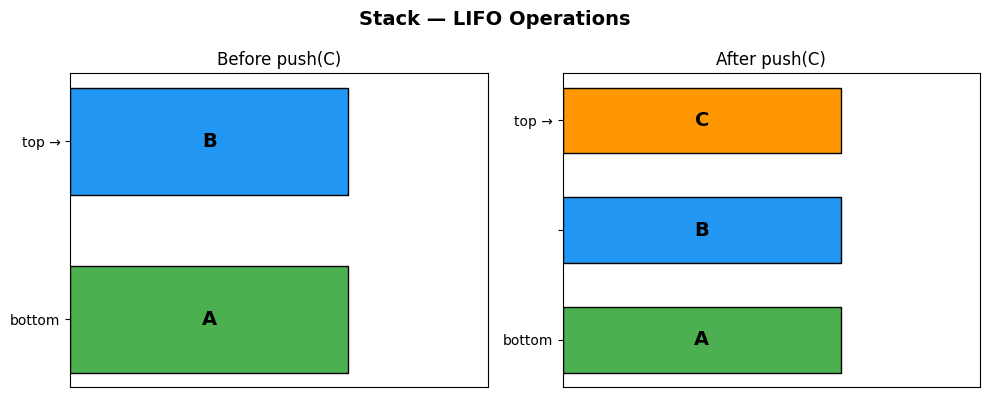

Stack visualization saved.


In [7]:
# Draw the stack before and after a single push to make LIFO behavior visible.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Stack — LIFO Operations", fontsize=14, fontweight="bold")

# Before push
ax = axes[0]
ax.set_title("Before push(C)")
stack_vals = ["A", "B"]
colors = ["#4CAF50", "#2196F3"]
for i, (val, color) in enumerate(zip(stack_vals, colors)):
    ax.barh(i, 1, color=color, edgecolor="black", height=0.6)
    ax.text(0.5, i, val, ha="center", va="center", fontsize=14, fontweight="bold")
ax.set_yticks(range(len(stack_vals)))
ax.set_yticklabels(["bottom", "top →"])
ax.set_xlim(0, 1.5)
ax.set_xticks([])

# After push
ax = axes[1]
ax.set_title("After push(C)")
stack_vals = ["A", "B", "C"]
colors = ["#4CAF50", "#2196F3", "#FF9800"]
for i, (val, color) in enumerate(zip(stack_vals, colors)):
    ax.barh(i, 1, color=color, edgecolor="black", height=0.6)
    ax.text(0.5, i, val, ha="center", va="center", fontsize=14, fontweight="bold")
ax.set_yticks(range(len(stack_vals)))
ax.set_yticklabels(["bottom", "", "top →"])
ax.set_xlim(0, 1.5)
ax.set_xticks([])

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "stack_visual.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Stack visualization saved.")

### Queue — FIFO Visualization

```
  Dequeue ←  [A] → [B] → [C]  ← Enqueue
             front          rear
```

Items enter at the rear and leave at the front. Both enqueue and dequeue are O(1) because the implementation maintains both front and rear pointers.

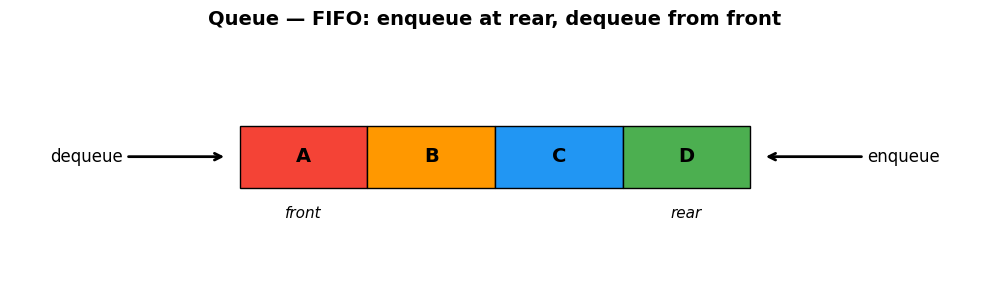

Queue visualization saved.


In [8]:
# Draw a simple queue with labeled dequeue and enqueue directions.
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_title("Queue — FIFO: enqueue at rear, dequeue from front",
             fontsize=14, fontweight="bold")

queue_vals = ["A", "B", "C", "D"]
colors = ["#F44336", "#FF9800", "#2196F3", "#4CAF50"]
for i, (val, color) in enumerate(zip(queue_vals, colors)):
    ax.barh(0, 1, left=i, color=color, edgecolor="black", height=0.5)
    ax.text(i + 0.5, 0, val, ha="center", va="center", fontsize=14, fontweight="bold")

# Arrows and labels
ax.annotate("dequeue", xy=(-0.1, 0), xytext=(-1.2, 0),
            fontsize=12, ha="center", va="center",
            arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("enqueue", xy=(len(queue_vals) + 0.1, 0),
            xytext=(len(queue_vals) + 1.2, 0),
            fontsize=12, ha="center", va="center",
            arrowprops=dict(arrowstyle="->", lw=2))
ax.text(0.5, -0.5, "front", ha="center", fontsize=11, style="italic")
ax.text(len(queue_vals) - 0.5, -0.5, "rear", ha="center", fontsize=11, style="italic")

ax.set_xlim(-1.8, len(queue_vals) + 1.8)
ax.set_ylim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "queue_visual.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Queue visualization saved.")

### LinkedList — Singly Linked Visualization

```
  head
   ↓
  [10] ->  [20] ->  [30] ->  None

  Prepend(5):   [5] ->  [10] ->  [20] -> [30] -> None    <- O(1)
  Append(40):   [10] -> [20] -> [30] -> [40] -> None   <- O(n) traversal
  Search(30):   [10] -> [20] -> [30] found!         <- O(n) worst case
```

The operations at the end require traversing the entire list. Prepend is O(1) because it only touches the head pointer.

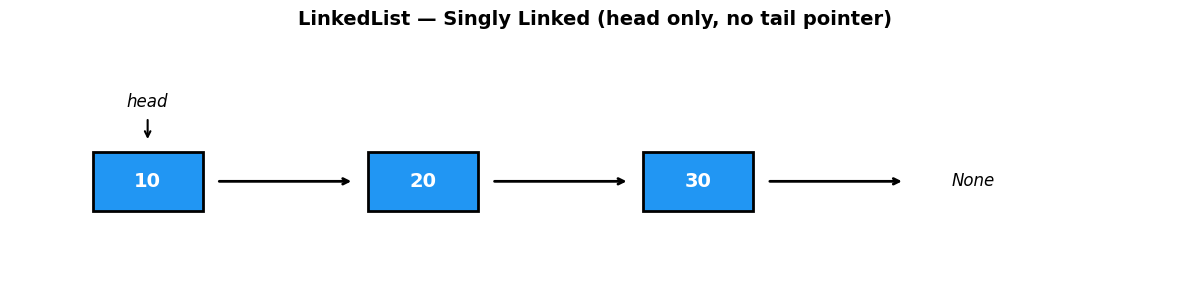

LinkedList visualization saved.


In [9]:
# Draw a singly linked list to emphasize head-only traversal.
fig, ax = plt.subplots(figsize=(12, 3))
ax.set_title("LinkedList — Singly Linked (head only, no tail pointer)",
             fontsize=14, fontweight="bold")

nodes = ["head\n↓", "10", "20", "30", "None"]
x_positions = [0, 0, 2, 4, 6]
# Draw nodes (skip head label and None)
for i in range(1, len(nodes) - 1):
    x = x_positions[i]
    rect = plt.Rectangle((x - 0.4, -0.3), 0.8, 0.6, fill=True,
                         facecolor="#2196F3", edgecolor="black", linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 0, nodes[i], ha="center", va="center",
            fontsize=14, fontweight="bold", color="white")
    # Arrow to next
    if i < len(nodes) - 2:
        ax.annotate("", xy=(x_positions[i+1] - 0.5, 0), xytext=(x + 0.5, 0),
                    arrowprops=dict(arrowstyle="->", lw=2))

# Arrow to None
ax.annotate("", xy=(5.5, 0), xytext=(4.5, 0),
            arrowprops=dict(arrowstyle="->", lw=2))
ax.text(6, 0, "None", ha="center", va="center", fontsize=12, style="italic")

# Head label
ax.text(0, 0.8, "head", ha="center", va="center", fontsize=12, style="italic")
ax.annotate("", xy=(0, 0.4), xytext=(0, 0.65),
            arrowprops=dict(arrowstyle="->", lw=1.5))

ax.set_xlim(-1, 7.5)
ax.set_ylim(-1, 1.5)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "linked_list_visual.png"), dpi=150, bbox_inches="tight")
plt.show()
print("LinkedList visualization saved.")

### Real-World Use Cases

| Structure | Best For | Examples |
|-----------|----------|----------|
| **Stack** | Reverse-order processing, nesting/recursion | Undo/redo, call stacks, parenthesis matching, DFS |
| **Queue** | First-come-first-served processing | Print queues, BFS, task scheduling, message buffers |
| **LinkedList** | Frequent insert/delete at known positions | Playlist management, adjacency lists, polynomial representation |

---

## Benchmark Methodology

### Approach

- Tool --> Python's `time.perf_counter()` from the standard library for high-resolution timing.
- Input sizes --> `[10, 100, 1_000, 5_000, 10_000]` elements.
- Repeats --> Each operation is timed 50 times per input size, and the mean runtime is reported.
- Isolation --> For every repetition, the notebook builds a fresh data structure before the timer starts, then measures only the target operation. Setup work is excluded from the recorded time.
- Worst-case targeting --> LinkedList `search` and `delete` target the tail node, forcing a full traversal. LinkedList `append` also traverses from head to tail because this implementation has no tail pointer.

### Limitations

- Python overhead --> Node allocation and interpreter dispatch add constant overhead that can obscure asymptotic behavior at very small sizes.
- Timer noise --> Microsecond-scale measurements are sensitive to OS scheduling, CPU frequency changes, and cache effects.
- Finite samples --> Five input sizes are enough to estimate growth trends, but they are still an approximation of asymptotic behavior.

---

Benchmark Execution

In [10]:
# Run every benchmark once so the notebook has one shared result set.
# This may take 30-60 seconds depending on the machine.
print("Running benchmarks...")
results = run_all_benchmarks()
print(f"Collected {len(results)} data points.")

# Convert to DataFrame for analysis
df = pd.DataFrame(results)
df.head(10)

Running benchmarks...


Collected 40 data points.


,structure,operation,n,repeats,total_time,avg_time
0,Stack,push,10,50,0.000014,2.700000e-07
1,Stack,push,100,50,0.000011,2.200000e-07
2,Stack,push,1000,50,0.000018,3.500000e-07
3,Stack,push,5000,50,0.000029,5.800000e-07
4,Stack,push,10000,50,0.000156,3.120000e-06
5,Stack,pop,10,50,0.000009,1.800000e-07
6,Stack,pop,100,50,0.000006,1.200000e-07
7,Stack,pop,1000,50,0.000009,1.900000e-07
8,Stack,pop,5000,50,0.000018,3.600000e-07
9,Stack,pop,10000,50,0.000021,4.100000e-07


In [11]:
# Save the raw benchmark data used by the report.
csv_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "benchmark_results.csv")
save_results_csv(results, csv_path)
print(f"Results saved to: {csv_path}")

Results saved to: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/benchmark_results.csv


---

## Performance Charts

In [12]:
def plot_structure(df, structure, filename):
    """Plot timing results for all operations of a given structure."""
    subset = df[df["structure"] == structure]
    operations = subset["operation"].unique()

    fig, ax = plt.subplots(figsize=(9, 5))
    markers = ["o", "s", "^", "D", "v", "<"]

    # Plot one line per operation so growth trends can be compared visually.
    for i, op in enumerate(operations):
        op_data = subset[subset["operation"] == op]
        ax.plot(op_data["n"], op_data["avg_time"] * 1_000_000,
                marker=markers[i % len(markers)], linewidth=2,
                markersize=7, label=op)

    ax.set_xlabel("Input Size (n)", fontsize=12)
    ax.set_ylabel("Average Time (microseconds)", fontsize=12)
    ax.set_title(f"{structure} — Operation Timings vs. Input Size",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(CHART_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

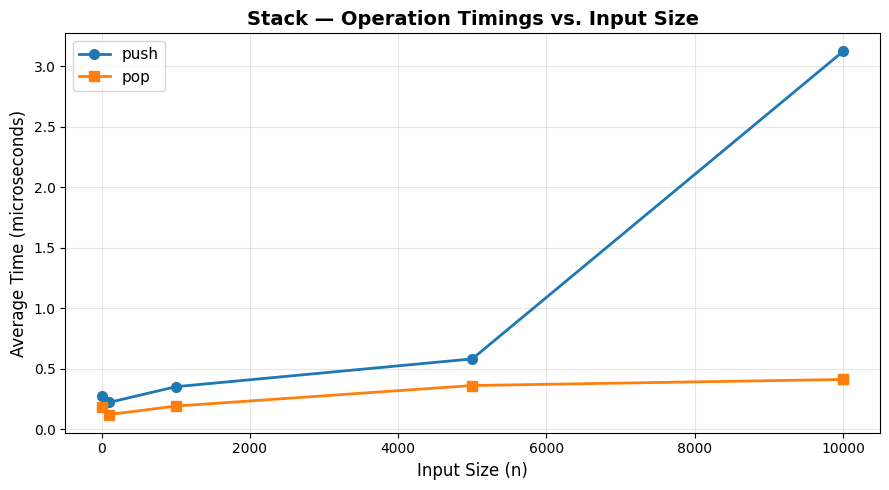

Saved: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts/stack_timings.png


In [13]:
# Generate the Stack timing chart.
plot_structure(df, "Stack", "stack_timings.png")

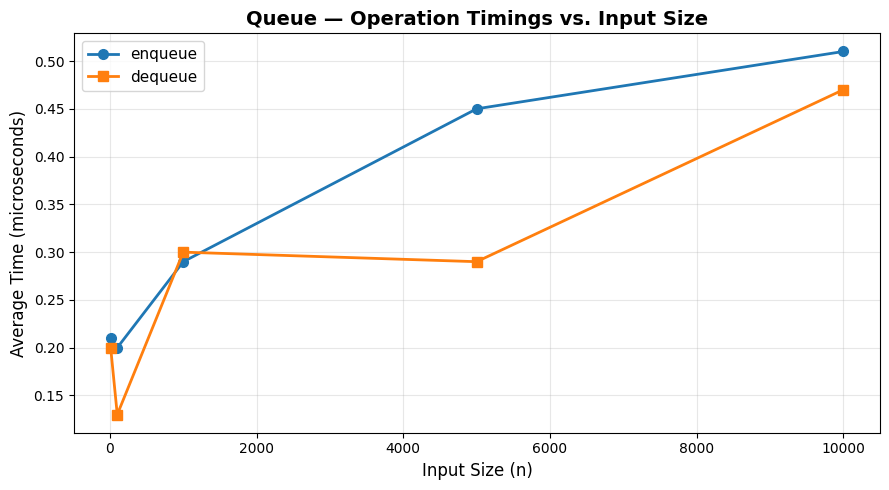

Saved: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts/queue_timings.png


In [14]:
# Generate the Queue timing chart.
plot_structure(df, "Queue", "queue_timings.png")

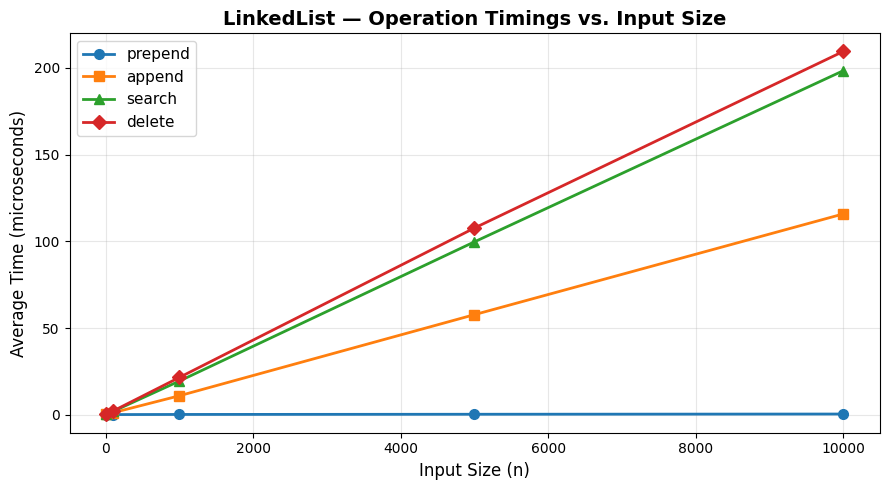

Saved: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts/linked_list_timings.png


In [15]:
# Generate the LinkedList timing chart.
plot_structure(df, "LinkedList", "linked_list_timings.png")

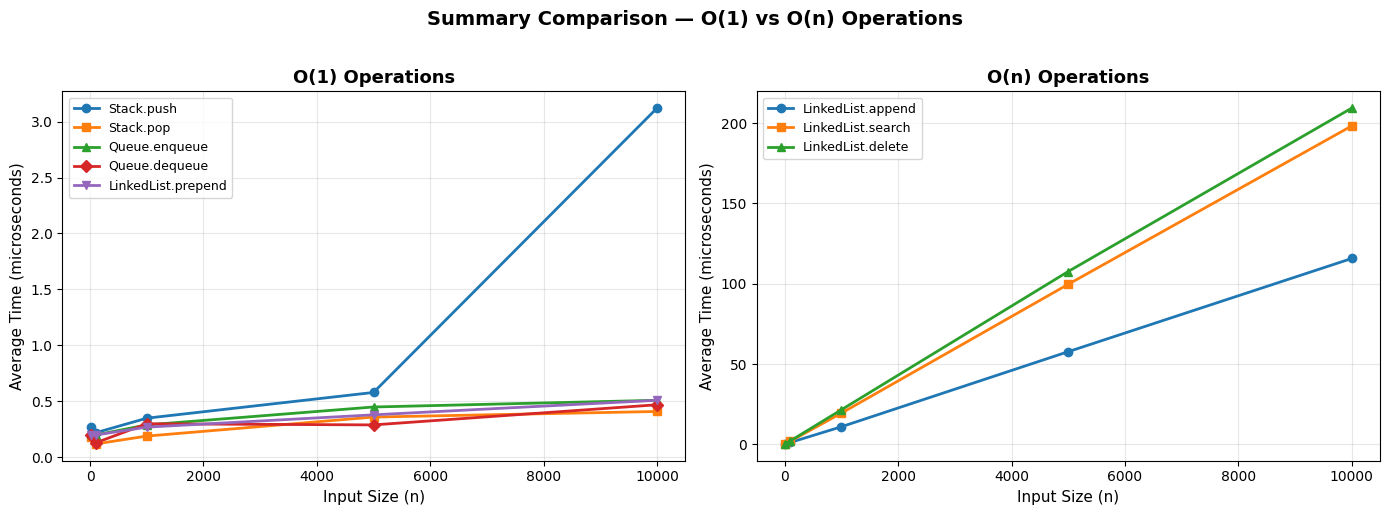

Saved: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts/summary_comparison.png


In [16]:
# Summary comparison: O(1) vs O(n) operations side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- O(1) Operations ---
ax = axes[0]
ax.set_title("O(1) Operations", fontsize=13, fontweight="bold")
o1_ops = [
    ("Stack", "push"), ("Stack", "pop"),
    ("Queue", "enqueue"), ("Queue", "dequeue"),
    ("LinkedList", "prepend"),
]
markers = ["o", "s", "^", "D", "v"]
for i, (struct, op) in enumerate(o1_ops):
    subset = df[(df["structure"] == struct) & (df["operation"] == op)]
    ax.plot(subset["n"], subset["avg_time"] * 1_000_000,
            marker=markers[i], linewidth=2, markersize=6,
            label=f"{struct}.{op}")
ax.set_xlabel("Input Size (n)", fontsize=11)
ax.set_ylabel("Average Time (microseconds)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- O(n) Operations ---
ax = axes[1]
ax.set_title("O(n) Operations", fontsize=13, fontweight="bold")
on_ops = [
    ("LinkedList", "append"), ("LinkedList", "search"),
    ("LinkedList", "delete"),
]
markers = ["o", "s", "^"]
for i, (struct, op) in enumerate(on_ops):
    subset = df[(df["structure"] == struct) & (df["operation"] == op)]
    ax.plot(subset["n"], subset["avg_time"] * 1_000_000,
            marker=markers[i], linewidth=2, markersize=6,
            label=f"{struct}.{op}")
ax.set_xlabel("Input Size (n)", fontsize=11)
ax.set_ylabel("Average Time (microseconds)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("Summary Comparison — O(1) vs O(n) Operations",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
path = os.path.join(CHART_DIR, "summary_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

---

## Prediction vs. Observation

The notebook measures prediction accuracy by comparing each operation's expected Big O growth exponent with the observed log-log slope from the benchmark data.

- `O(1)` corresponds to an expected exponent of `0`.
- `O(n)` corresponds to an expected exponent of `1`.
- The closer the observed slope is to the expected exponent, the more accurate the prediction.

In [17]:
import math


def expected_exponent(big_o: str) -> float:
    """Map a Big O class to its expected growth exponent."""
    mapping = {
        "O(1)": 0.0,
        "O(n)": 1.0,
    }
    return mapping[big_o]


# -------------------------------------------------------------- observed_exponent()
def observed_exponent(subset: pd.DataFrame) -> float:
    """Estimate the empirical growth exponent from log-log regression.

    Args:
        subset: Benchmark rows for one operation.

    Returns:
        The slope of `log(time)` vs. `log(n)`.
    """
    ordered = subset.sort_values("n")
    xs = [math.log(float(n)) for n in ordered["n"]]
    ys = [math.log(float(t)) for t in ordered["avg_time"]]

    x_mean = sum(xs) / len(xs)
    y_mean = sum(ys) / len(ys)
    numerator = sum((x - x_mean) * (y - y_mean) for x, y in zip(xs, ys))
    denominator = sum((x - x_mean) ** 2 for x in xs)
    return numerator / denominator if denominator else float("nan")
# -------------------------------------------------------------- end observed_exponent()


# -------------------------------------------------------------- classify_match()
def classify_match(expected: float, observed: float) -> str:
    """Classify the agreement between predicted and observed exponents."""
    error = abs(observed - expected)
    if error <= 0.20:
        return "Strong"
    if error <= 0.40:
        return "Moderate"
    return "Weak"
# -------------------------------------------------------------- end classify_match()


# Limit the accuracy check to operations that are both implemented and benchmarked.
accuracy_rows = []
checks = [
    ("Stack", "push", "O(1)"),
    ("Stack", "pop", "O(1)"),
    ("Queue", "enqueue", "O(1)"),
    ("Queue", "dequeue", "O(1)"),
    ("LinkedList", "prepend", "O(1)"),
    ("LinkedList", "append", "O(n)"),
    ("LinkedList", "search", "O(n)"),
    ("LinkedList", "delete", "O(n)"),
]

# Measure how far the observed growth exponent is from the predicted one.
for struct, op, predicted in checks:
    subset = df[(df["structure"] == struct) & (df["operation"] == op)]
    expected = expected_exponent(predicted)
    observed = observed_exponent(subset)
    error = abs(observed - expected)
    accuracy_rows.append({
        "Structure": struct,
        "Operation": op,
        "Predicted": predicted,
        "Expected Exponent": expected,
        "Observed Exponent": observed,
        "Absolute Error": error,
        "Match": classify_match(expected, observed),
    })

# Format the results so the notebook table is easy to read at a glance.
df_accuracy = pd.DataFrame(accuracy_rows)
df_accuracy_display = df_accuracy.copy()
df_accuracy_display["Expected Exponent"] = df_accuracy_display["Expected Exponent"].map(lambda value: f"{value:.0f}")
df_accuracy_display["Observed Exponent"] = df_accuracy_display["Observed Exponent"].map(lambda value: f"{value:.2f}")
df_accuracy_display["Absolute Error"] = df_accuracy_display["Absolute Error"].map(lambda value: f"{value:.2f}")
df_accuracy_display

,Structure,Operation,Predicted,Expected Exponent,Observed Exponent,Absolute Error,Match
0,Stack,push,O(1),0,0.29,0.29,Moderate
1,Stack,pop,O(1),0,0.14,0.14,Strong
2,Queue,enqueue,O(1),0,0.14,0.14,Strong
3,Queue,dequeue,O(1),0,0.13,0.13,Strong
4,LinkedList,prepend,O(1),0,0.13,0.13,Strong
5,LinkedList,append,O(n),1,0.85,0.15,Strong
6,LinkedList,search,O(n),1,0.93,0.07,Strong
7,LinkedList,delete,O(n),1,0.90,0.10,Strong


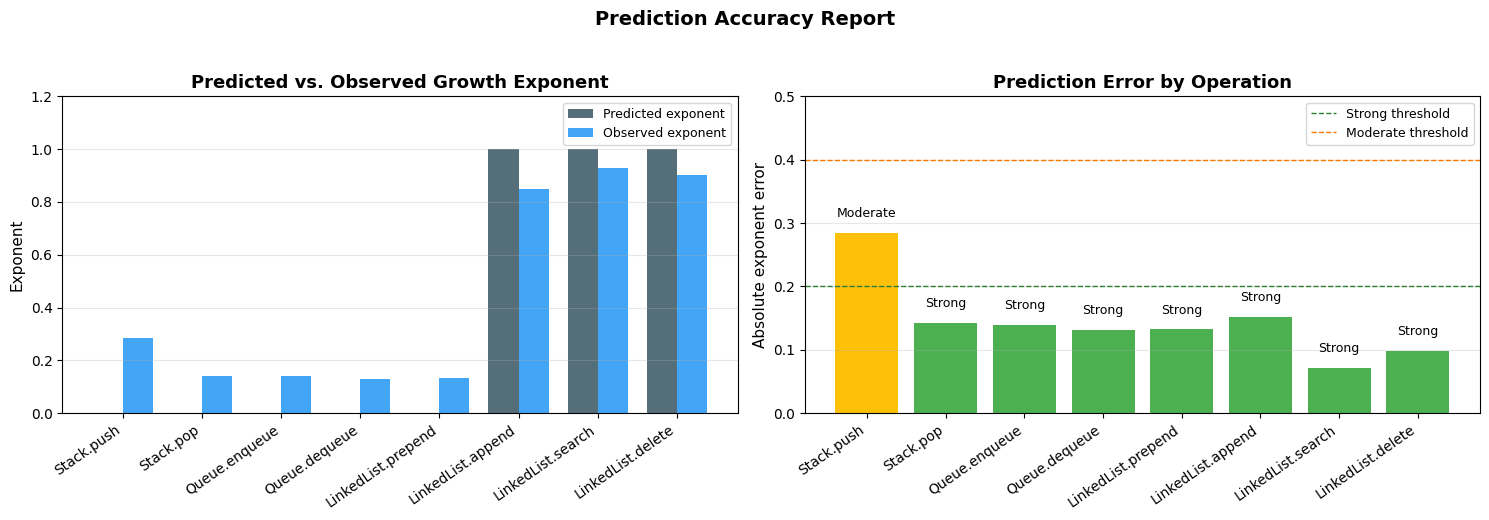

Saved: /Volumes/P-SSD/CSC506-Projects/CTA-1/analysis/charts/prediction_accuracy.png


In [18]:
# Build chart labels and color mapping from the accuracy summary table.
labels = [f"{row.Structure}.{row.Operation}" for row in df_accuracy.itertuples()]
x_positions = list(range(len(labels)))
width = 0.38
colors = {
    "Strong": "#4CAF50",
    "Moderate": "#FFC107",
    "Weak": "#F44336",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Predicted vs observed exponent ---
ax = axes[0]
ax.bar(
    [x - width / 2 for x in x_positions],
    df_accuracy["Expected Exponent"],
    width=width,
    label="Predicted exponent",
    color="#546E7A",
)
ax.bar(
    [x + width / 2 for x in x_positions],
    df_accuracy["Observed Exponent"],
    width=width,
    label="Observed exponent",
    color="#42A5F5",
)
ax.set_title("Predicted vs. Observed Growth Exponent", fontsize=13, fontweight="bold")
ax.set_ylabel("Exponent", fontsize=11)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylim(0, 1.2)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=9)

# --- Absolute error by operation ---
ax = axes[1]
bar_colors = [colors[match] for match in df_accuracy["Match"]]
ax.bar(x_positions, df_accuracy["Absolute Error"], color=bar_colors)
ax.axhline(0.20, color="#2E7D32", linestyle="--", linewidth=1, label="Strong threshold")
ax.axhline(0.40, color="#F57C00", linestyle="--", linewidth=1, label="Moderate threshold")
ax.set_title("Prediction Error by Operation", fontsize=13, fontweight="bold")
ax.set_ylabel("Absolute exponent error", fontsize=11)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylim(0, max(0.5, df_accuracy["Absolute Error"].max() + 0.1))
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=9)

# Label each bar with the qualitative match classification.
for x, error, match in zip(x_positions, df_accuracy["Absolute Error"], df_accuracy["Match"]):
    ax.text(x, error + 0.02, match, ha="center", va="bottom", fontsize=9)

fig.suptitle("Prediction Accuracy Report", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
path = os.path.join(CHART_DIR, "prediction_accuracy.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

### Interpretation

- `O(1)` operations should produce observed exponents close to `0`, meaning runtime stays nearly flat as `n` grows.
- `O(n)` operations should produce observed exponents close to `1`, meaning runtime scales proportionally with input size.
- Absolute error <= `0.20` is labeled `Strong`, error between `0.21` and `0.40` is `Moderate`, and larger gaps are `Weak`.
- Because the benchmark now isolates the target operation on a fresh structure each repetition, the accuracy chart is a cleaner comparison between theory and measurement.

---

## When to Use Each Structure

| Criterion | Stack | Queue | LinkedList |
|-----------|-------|-------|------------|
| **Access pattern** | Last added item only | First added item only | Any position (by traversal) |
| **Primary insert** | O(1) — push at top | O(1) — enqueue at rear | O(1) — prepend at head |
| **Insert at back** | N/A | O(1) — enqueue | O(n) — append (no tail ptr) |
| **Primary removal** | O(1) — pop from top | O(1) — dequeue from front | O(n) — delete by value; O(1) only if head matches |
| **Search** | Not supported directly | Not supported directly | O(n) — linear scan |
| **Memory** | One pointer per node | One pointer per node | One pointer per node |

### Decision Guide

1. Need reverse-order (LIFO) processing? -->  Use a Stack. Example: undo/redo, DFS, expression parsing.
2. Need first-come-first-served (FIFO) processing? --> Use a Queue. Example: BFS, task scheduling, print jobs.
3. Need to insert/delete at arbitrary positions? --> Use a LinkedList. Example: playlist management, maintaining sorted insertion order.
4. Need fast search? -->  None of these — consider a hash table or balanced BST instead.

---

## Conclusion

This corrected analysis confirms that the data structure operations behave as predicted by Big O:

- Stack and Queue primary operations (push/pop, enqueue/dequeue) remain effectively constant-time, with observed exponents close to `0`.
- LinkedList operations that require traversal (append, search, and delete-by-value at the tail) show near-linear growth, with observed exponents close to `1`.
- LinkedList prepend remains constant-time because it updates only the head pointer.
- The prediction-accuracy chart shows that the observed growth rates closely match the theoretical expectations after isolating the target operation from setup work.

These results provide both a theoretical and empirical basis for choosing the right data structure for a given workload.